In [22]:
import math
import torch
import torch.nn as nn
from transformers import ViTModel


# =====================
# Attention
# =====================
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)
        return out, attn


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads")

        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)

        self.out = nn.Linear(d_model, d_model)
        self.attn = ScaledDotProductAttention(dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)

        def transform(x, linear):
            x = linear(x)
            x = x.view(B, -1, self.n_heads, self.d_k)
            return x.transpose(1, 2)

        q = transform(q, self.q_linear)
        k = transform(k, self.k_linear)
        v = transform(v, self.v_linear)

        out, attn = self.attn(q, k, v, mask)

        out = out.transpose(1, 2).contiguous().view(B, -1, self.n_heads * self.d_k)
        out = self.out(out)
        out = self.dropout(out)

        return out, attn


# =====================
# Feed Forward
# =====================
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


# =====================
# Decoder Block
# =====================
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, x, encoder_feats, mask=None):
        _x, self_attn = self.self_attn(x, x, x, mask)
        x = self.norm1(x + _x)

        _x, cross_attn = self.cross_attn(x, encoder_feats, encoder_feats)
        x = self.norm2(x + _x)

        _x = self.ffn(x)
        x = self.norm3(x + _x)

        return x, self_attn, cross_attn


# =====================
# Decoder
# =====================
class GPTDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        n_heads,
        num_layers,
        d_ff,
        max_len,
        vision_dim=768,
        dropout=0.1,
        pad_token_id=None,
    ):
        super().__init__()

        self.pad_token_id = pad_token_id
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_len, d_model)
        self.visual_proj = nn.Linear(vision_dim, d_model)
        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            DecoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # weight tying
        self.lm_head.weight = self.embedding.weight

    def make_decoder_mask(self, input_ids):
        B, T = input_ids.shape
        causal = torch.tril(torch.ones(T, T, device=input_ids.device)).unsqueeze(0).unsqueeze(0)

        if self.pad_token_id is None:
            return causal

        pad_mask = (input_ids != self.pad_token_id).unsqueeze(1).unsqueeze(2)  # (B,1,1,T)
        return causal * pad_mask

    def forward(self, input_ids, encoder_feats):
        B, T = input_ids.shape

        positions = torch.arange(0, T, device=input_ids.device).unsqueeze(0).expand(B, T)

        x = self.embedding(input_ids) + self.pos_embedding(positions)
        x = self.dropout(x)

        encoder_feats = self.visual_proj(encoder_feats)
        mask = self.make_decoder_mask(input_ids)

        self_attns = []
        cross_attns = []

        for layer in self.layers:
            x, self_attn, cross_attn = layer(x, encoder_feats, mask)
            self_attns.append(self_attn)
            cross_attns.append(cross_attn)

        logits = self.lm_head(x)
        return logits, self_attns, cross_attns


# =====================
# Full Multimodal Model
# =====================
class MultiModalModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=256,
        n_heads=4,
        num_layers=4,
        d_ff=1024,
        max_len=32,
        vision_dim=768,
        dropout=0.1,
        pad_token_id=None,
    ):
        super().__init__()

        self.decoder = GPTDecoder(
            vocab_size=vocab_size,
            d_model=d_model,
            n_heads=n_heads,
            num_layers=num_layers,
            d_ff=d_ff,
            max_len=max_len,
            vision_dim=vision_dim,
            dropout=dropout,
            pad_token_id=pad_token_id,
        )

    def forward(self, input_ids, encoder_feats):
        return self.decoder(input_ids, encoder_feats)

In [23]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d adityajn105/flickr8k


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
flickr8k.zip: Skipping, found more recently modified local copy (use --force to force download)


In [24]:
import zipfile, os

base_path = "/content/data/flickr8k"
os.makedirs(base_path, exist_ok=True)

with zipfile.ZipFile("flickr8k.zip", 'r') as zip_ref:
    zip_ref.extractall(base_path)

print("✅ Done!")

✅ Done!


In [25]:
import pandas as pd

ROOT = "/content/data/flickr8k"

CAPTION_FILE = os.path.join(ROOT, "captions.txt")
IMAGE_DIR = os.path.join(ROOT, "Images")

rows = []

with open(CAPTION_FILE, "r", encoding="utf-8") as f:
    next(f)
    for line in f:
        parts = line.strip().split(",", 1)
        img_name, caption = parts

        img_path = os.path.join(IMAGE_DIR, img_name)

        if os.path.exists(img_path):
            rows.append({
                "image": img_name,
                "caption": caption
            })

df = pd.DataFrame(rows)
df.to_csv("/content/captions.csv", index=False)

print("✅ dataset ready:", len(df))

✅ dataset ready: 40455


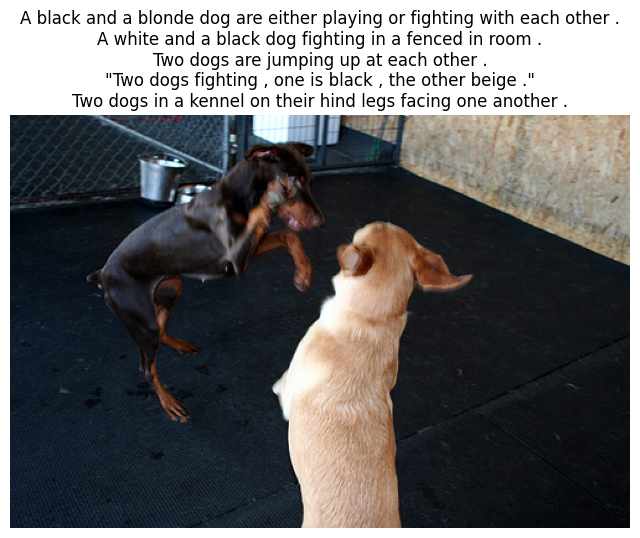

In [26]:
import random
from PIL import Image
import matplotlib.pyplot as plt

ROOT = "/content/data/flickr8k"
IMAGES_DIR = os.path.join(ROOT, "Images")
CAPTION_FILE = os.path.join(ROOT, "captions.txt")

captions = {}

with open(CAPTION_FILE, "r", encoding="utf-8") as f:
    next(f)
    for line in f:
        parts = line.strip().split(",", 1)
        if len(parts) != 2:
            continue
        img_name, caption = parts

        if img_name not in captions:
            captions[img_name] = []
        captions[img_name].append(caption)

img_name = random.choice(list(captions.keys()))
img_path = os.path.join(IMAGES_DIR, img_name)

img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("\n".join(captions[img_name][:5]))
plt.show()

In [27]:
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, ViTImageProcessor, ViTModel

In [28]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

tokenizer.add_special_tokens({
    "bos_token": "<bos>",
    "eos_token": "<eos>"
})

tokenizer.pad_token = tokenizer.eos_token

print("Vocab size:", len(tokenizer))

Vocab size: 50259


In [29]:
processor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224"
)

In [30]:
ROOT = "/content/data/flickr8k"
IMAGES_DIR = os.path.join(ROOT, "Images")
CAPTION_FILE = os.path.join(ROOT, "captions.txt")

rows = []

with open(CAPTION_FILE, "r", encoding="utf-8") as f:
    next(f)
    for line in f:
        parts = line.strip().split(",", 1)
        if len(parts) != 2:
            continue

        img_name, caption = parts

        rows.append({
            "image_path": os.path.join(IMAGES_DIR, img_name),
            "caption": caption
        })

df = pd.DataFrame(rows)
df.to_csv("/content/train_caption_rows.csv", index=False)

print("CSV generated!")
print("rows:", len(df))
print(df.head())

CSV generated!
rows: 40455
                                          image_path  \
0  /content/data/flickr8k/Images/1000268201_693b0...   
1  /content/data/flickr8k/Images/1000268201_693b0...   
2  /content/data/flickr8k/Images/1000268201_693b0...   
3  /content/data/flickr8k/Images/1000268201_693b0...   
4  /content/data/flickr8k/Images/1000268201_693b0...   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  


In [31]:
class FlickrDataset(Dataset):
    def __init__(self, df, tokenizer, processor, max_len=32):
        self.df = df
        self.tokenizer = tokenizer
        self.processor = processor
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # image
        image = Image.open(row["image_path"]).convert("RGB")
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)

        # caption
        caption = "<bos> " + row["caption"] + " <eos>"

        tokens = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        input_ids = tokens.input_ids.squeeze(0)

        # shift labels
        labels = input_ids.clone()
        labels[:-1] = input_ids[1:]
        labels[-1] = -100

        return {
            "pixel_values": pixel_values,
            "input_ids": input_ids,
            "labels": labels
        }

In [32]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

train_dataset = FlickrDataset(train_df, tokenizer, processor)
val_dataset   = FlickrDataset(val_df, tokenizer, processor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MultiModalModel(
    vocab_size=len(tokenizer),
    d_model=512,
    n_heads=4,
    num_layers=4,
    d_ff=1024,
    max_len=32,
    vision_dim=768,
    dropout=0.1,
    pad_token_id=tokenizer.pad_token_id
).to(device)

In [34]:
vit = ViTModel.from_pretrained("google/vit-base-patch16-224").to(device)

for param in vit.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [35]:
import torch
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def evaluate_bleu(model, vit, val_loader, tokenizer, device, max_len=30):
    model.eval()
    references = []
    hypotheses = []
    smooth = SmoothingFunction().method1

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            # ViT encoder
            vit_outputs = vit(pixel_values=pixel_values)
            encoder_feats = vit_outputs.last_hidden_state

            # greedy decoding
            generated = input_ids[:, :1]
            for _ in range(max_len):
                logits, _, _ = model(generated, encoder_feats)
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                generated = torch.cat([generated, next_token], dim=1)

            pred_ids = generated.cpu().tolist()
            label_ids = labels.cpu().tolist()

            for pred, gold in zip(pred_ids, label_ids):
                # prediction
                pred_text = tokenizer.decode(pred, skip_special_tokens=True).strip()
                pred_tokens = pred_text.split()

                # ground truth
                gold_clean = [x for x in gold if x != -100]
                gold_text = tokenizer.decode(gold_clean, skip_special_tokens=True).strip()
                gold_tokens = gold_text.split()

                if len(pred_tokens) > 0 and len(gold_tokens) > 0:
                    hypotheses.append(pred_tokens)
                    references.append([gold_tokens])

    bleu1 = corpus_bleu(
        references, hypotheses,
        weights=(1.0, 0, 0, 0),
        smoothing_function=smooth
    )
    bleu2 = corpus_bleu(
        references, hypotheses,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smooth
    )
    bleu3 = corpus_bleu(
        references, hypotheses,
        weights=(1/3, 1/3, 1/3, 0),
        smoothing_function=smooth
    )
    bleu4 = corpus_bleu(
        references, hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    return {
        "bleu1": bleu1,
        "bleu2": bleu2,
        "bleu3": bleu3,
        "bleu4": bleu4
    }

In [36]:
import torch.nn as nn

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

num_epochs = 10
history = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for step, batch in enumerate(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        # ViT forward
        with torch.no_grad():
            vit_outputs = vit(pixel_values=pixel_values)
            encoder_feats = vit_outputs.last_hidden_state

        # decoder
        logits, _, _ = model(input_ids, encoder_feats)

        B, T, V = logits.shape
        loss = loss_fn(
            logits.reshape(B * T, V),
            labels.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if step % 100 == 0:
            print(f"Epoch {epoch+1} | Step {step} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)

    bleu_scores = evaluate_bleu(
        model=model,
        vit=vit,
        val_loader=val_loader,
        tokenizer=tokenizer,
        device=device,
        max_len=30
    )

    history.append({
        "epoch": epoch + 1,
        "loss": avg_loss,
        "bleu1": bleu_scores["bleu1"],
        "bleu2": bleu_scores["bleu2"],
        "bleu3": bleu_scores["bleu3"],
        "bleu4": bleu_scores["bleu4"]
    })

    print(
        f"Epoch {epoch+1} DONE | "
        f"Avg Loss: {avg_loss:.4f} | "
        f"BLEU-1: {bleu_scores['bleu1']:.4f} | "
        f"BLEU-2: {bleu_scores['bleu2']:.4f} | "
        f"BLEU-3: {bleu_scores['bleu3']:.4f} | "
        f"BLEU-4: {bleu_scores['bleu4']:.4f}"
    )

Epoch 1 | Step 0 | Loss: 126.6838
Epoch 1 | Step 100 | Loss: 17.4594
Epoch 1 | Step 200 | Loss: 12.6091
Epoch 1 | Step 300 | Loss: 10.5763
Epoch 1 | Step 400 | Loss: 9.4632
Epoch 1 | Step 500 | Loss: 8.1452
Epoch 1 | Step 600 | Loss: 8.6588
Epoch 1 | Step 700 | Loss: 7.3930
Epoch 1 | Step 800 | Loss: 6.7168
Epoch 1 | Step 900 | Loss: 6.6241
Epoch 1 | Step 1000 | Loss: 5.7264
Epoch 1 | Step 1100 | Loss: 5.3125
Epoch 1 DONE | Avg Loss: 10.3462 | BLEU-1: 0.2280 | BLEU-2: 0.0854 | BLEU-3: 0.0305 | BLEU-4: 0.0127
Epoch 2 | Step 0 | Loss: 5.8605
Epoch 2 | Step 100 | Loss: 5.3201
Epoch 2 | Step 200 | Loss: 4.8865
Epoch 2 | Step 300 | Loss: 5.0762
Epoch 2 | Step 400 | Loss: 4.8056
Epoch 2 | Step 500 | Loss: 5.7495
Epoch 2 | Step 600 | Loss: 4.5777
Epoch 2 | Step 700 | Loss: 3.7578
Epoch 2 | Step 800 | Loss: 3.7036
Epoch 2 | Step 900 | Loss: 4.2792
Epoch 2 | Step 1000 | Loss: 3.8527
Epoch 2 | Step 1100 | Loss: 4.5594
Epoch 2 DONE | Avg Loss: 4.6599 | BLEU-1: 0.2524 | BLEU-2: 0.1177 | BLEU-3: 0.

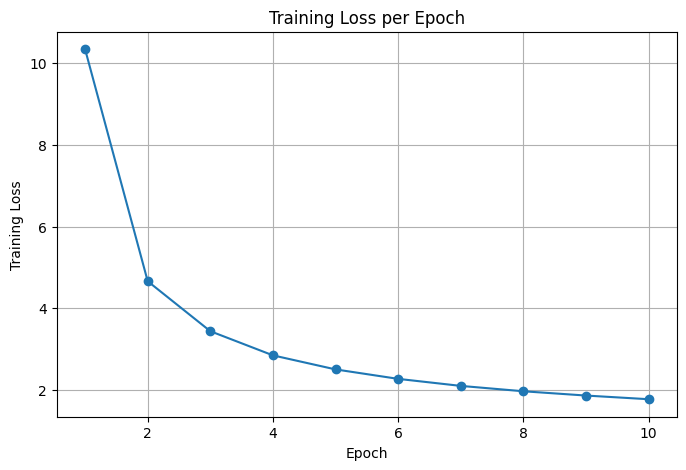

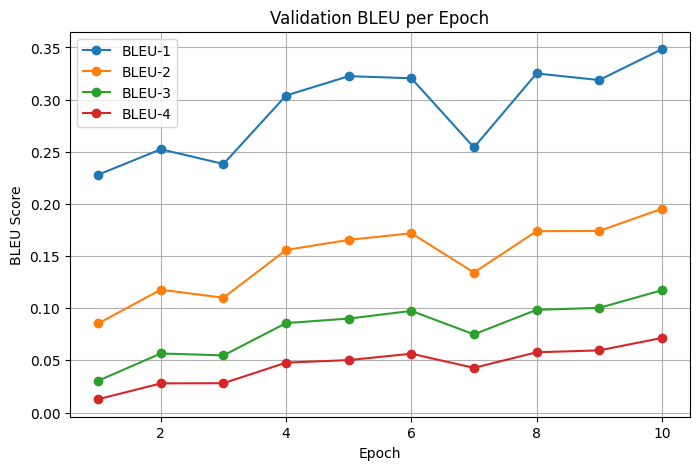

In [37]:
import matplotlib.pyplot as plt

epochs = [x["epoch"] for x in history]
losses = [x["loss"] for x in history]
bleu1 = [x["bleu1"] for x in history]
bleu2 = [x["bleu2"] for x in history]
bleu3 = [x["bleu3"] for x in history]
bleu4 = [x["bleu4"] for x in history]

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(epochs, losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss per Epoch")
plt.grid(True)
plt.show()

# BLEU curve
plt.figure(figsize=(8, 5))
plt.plot(epochs, bleu1, marker='o', label='BLEU-1')
plt.plot(epochs, bleu2, marker='o', label='BLEU-2')
plt.plot(epochs, bleu3, marker='o', label='BLEU-3')
plt.plot(epochs, bleu4, marker='o', label='BLEU-4')
plt.xlabel("Epoch")
plt.ylabel("BLEU Score")
plt.title("Validation BLEU per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
import torch.nn.functional as F

def generate_caption(model, vit, processor, tokenizer, image, device, max_len=30):
    model.eval()
    vit.eval()

    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        encoder_feats = vit(pixel_values=pixel_values).last_hidden_state

    input_ids = torch.tensor([[tokenizer.bos_token_id]], device=device)
    generated = []

    for _ in range(max_len):
        with torch.no_grad():
            logits, _, _ = model(input_ids, encoder_feats)

        next_token_logits = logits[:, -1, :]

        # Top-k
        k = 50
        values, indices = torch.topk(next_token_logits, k)

        probs = F.softmax(values / 0.8, dim=-1)
        next_token = indices.gather(-1, torch.multinomial(probs, 1))

        token_id = next_token.item()
        if token_id == tokenizer.eos_token_id:
            break

        generated.append(token_id)

        input_ids = torch.cat([input_ids, next_token], dim=1)

    caption = tokenizer.decode(generated, skip_special_tokens=True)
    return caption

In [39]:
captions_dict = {}

with open("/content/data/flickr8k/captions.txt", "r", encoding="utf-8") as f:
    next(f)
    for line in f:
        parts = line.strip().split(",", 1)
        if len(parts) != 2:
            continue

        img_name, caption = parts

        if img_name not in captions_dict:
            captions_dict[img_name] = []
        captions_dict[img_name].append(caption)

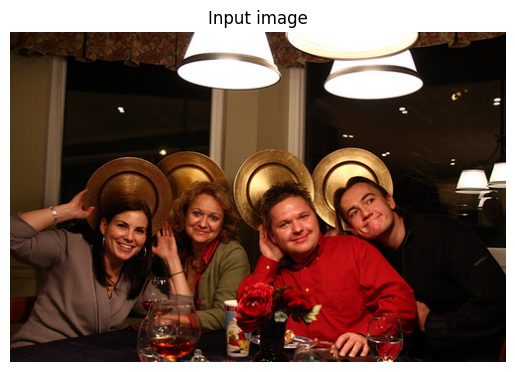

Pred:  A group of people are standing in front of her in a table . 

Ground Truth:
1. Four people make a silly pose at the dinner table .
2. Four people smile and hold golden plates behind their heads .
3. friends posing for a picture while holding plates
4. Two men and two women hold gold plates behind their heads .
5. Two men and women pose for a camera with large gold plates held behind their heads .


In [40]:
img_name = random.choice(os.listdir("/content/data/flickr8k/Images"))
img_path = os.path.join("/content/data/flickr8k/Images", img_name)

image = Image.open(img_path).convert("RGB")


pred_caption = generate_caption(model, vit, processor, tokenizer, image, device)

gt_captions = captions_dict.get(img_name, [])

plt.imshow(image)
plt.axis("off")
plt.title("Input image")
plt.show()

print("Pred:", pred_caption)
print("\nGround Truth:")
for i, cap in enumerate(gt_captions):
    print(f"{i+1}. {cap}")